# TRABAJO PRÁCTICO N° 3: Modelado y Simulación por medio de Múltiples Agentes

**Pontificia Universidad Católica Argentina (UCA)**
**Facultad de Química e Ingeniería del Rosario**
**Licenciatura en Ciencias de Datos**

**Asignatura:** Simulación y Procesos Estocásticos
* **Docentes:** Dr. Alejandro Mezio (Teoría) | Dr. Luis Herrera (Práctica)
* **Lugar y Fecha:** Rosario, Santa Fe - 2026

---
### **GRUPO DE TRABAJO**
* Andrisani, Facundo
* Feser, Ignacio
* Lauria, Francisco
* Viccei, Tomas
---

## INTRODUCCIÓN Y MARCO TEÓRICO

El presente trabajo práctico aborda el **Modelado Basado en Agentes (ABM)**, un paradigma de simulación estocástica donde el foco se desplaza desde las ecuaciones agregadas macrosocópicas hacia la definición de reglas de comportamiento individuales a nivel microscópico (autómatas celulares).

A través del clásico **Modelo de Segregación de Thomas Schelling**, exploraremos cómo decisiones individuales miopes, basadas exclusivamente en la evaluación de una vecindad local (Vecindad de Moore), generan comportamientos emergentes a nivel global. El objetivo central es visualizar cómo una retícula bidimensional evoluciona temporalmente bajo dos dinámicas de preferencias distintas: la búsqueda de la *minoría* (que conduce a un estado de frustración sistémica) y la búsqueda de la *mayoría* (que culmina en una segregación espacial estacionaria).

## Librerias

In [38]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.signal import convolve2d
from tqdm.notebook import tqdm

## 1. Dinámica 1: Búsqueda de la Minoría y el Estado Frustrado

**Consigna:** Implementar en Python la Dinámica 1 referida al modelo de Schelling, generando la salida gráfica de por lo menos seis (6) instancias, pensando que la última instancia converge al estado estacionario.

> **Aclaración Metodológica:** En el apunte original de la cátedra se enuncia para la Dinámica 1 que *"la situación favorable para un agente es participar de la mayoría"*. Sin embargo, la descripción del fenómeno en la Figura 1 y la definición del "estado frustrado" corresponden teóricamente a la preferencia opuesta: el incentivo a ser *diferente* o especial en el vecindario. Por lo tanto, en esta implementación hemos programado la regla lógica congruente con la frustración del sistema: un agente está "contento" únicamente si pertenece a la **minoría** de su vecindad (por ejemplo, $\le 4$ celdas de su mismo grupo sobre un total de $9$ posiciones posibles, incluyéndose a sí mismo).

A continuación, se desarrolla el motor del Autómata Celular orientado a objetos para simular este comportamiento.

Iniciando Simulación: Dinámica 1...
[*] Inicio (Mudanza 0): 1609 agentes descontentos (64.36%)
[*] Progreso (Mudanza 50): 1543 agentes descontentos (61.72%)
[*] Progreso (Mudanza 100): 1447 agentes descontentos (57.88%)
[*] Progreso (Mudanza 300): 1143 agentes descontentos (45.72%)
[*] Progreso (Mudanza 800): 650 agentes descontentos (26.00%)
[*] Progreso (Mudanza 1500): 339 agentes descontentos (13.56%)
[*] Simulación pausada tras 1500 mudanzas.
[*] ESTADO FRUSTRADO DETECTADO: El sistema se estancó con 339 agentes perpetuamente descontentos (13.56%).


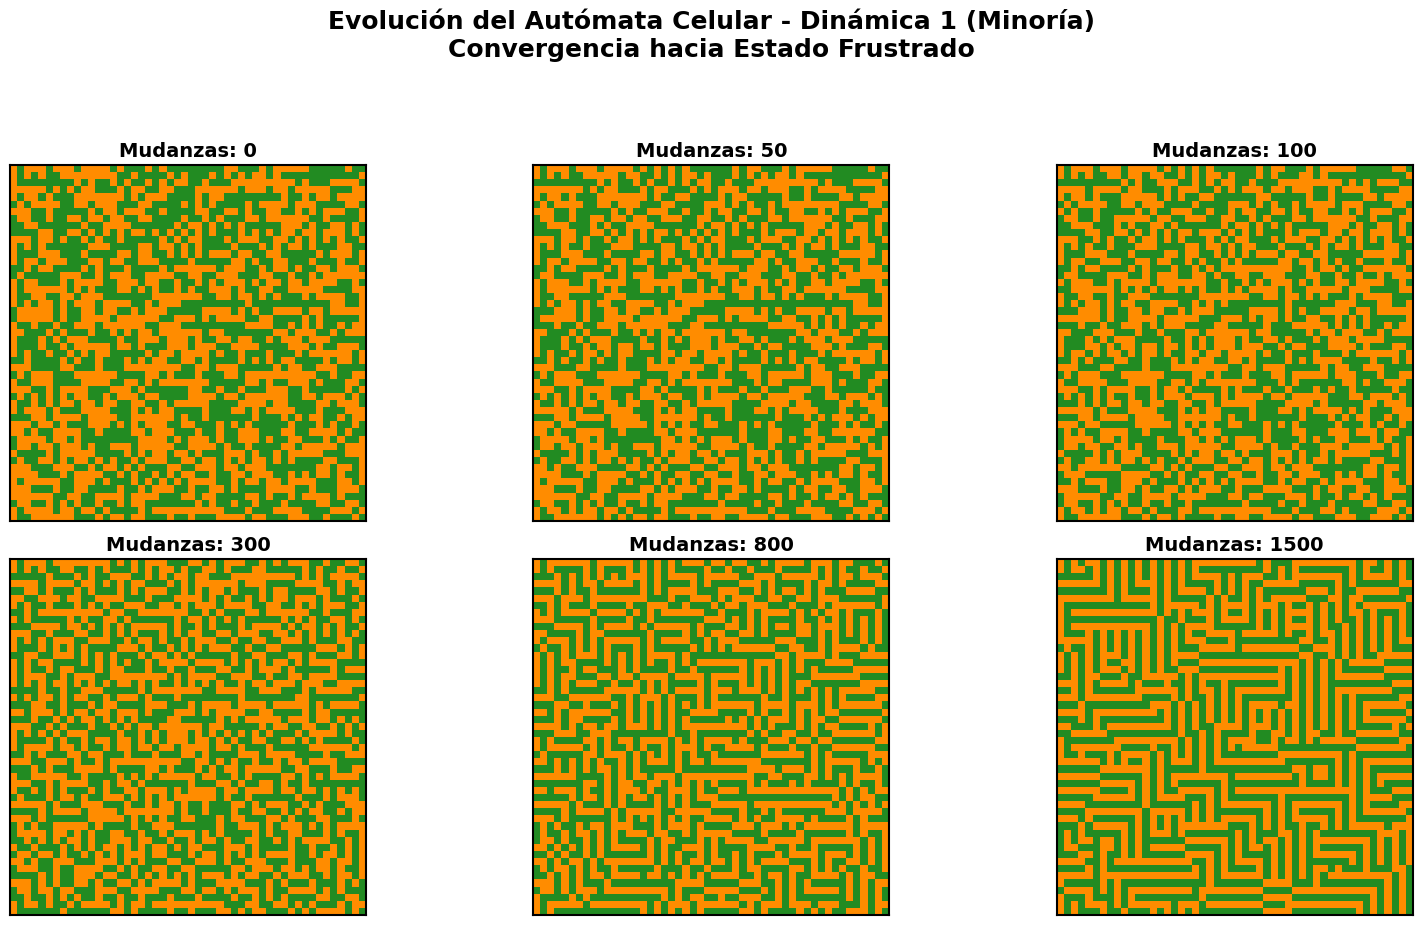

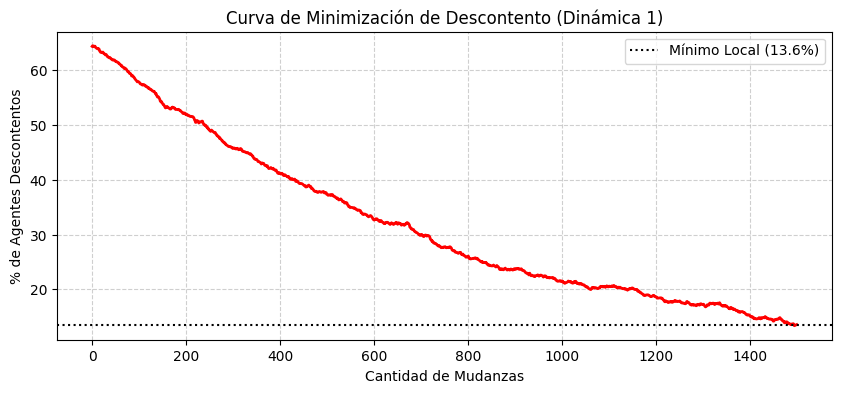

In [39]:
class ModeloSchelling:
    def __init__(self, n_size=50, dinamica=1):
        self.n_size = n_size
        self.dinamica = dinamica
        self.grid = np.random.choice([1, -1], size=(n_size, n_size))
        self.kernel = np.ones((3, 3), dtype=int)

        # Listas para guardar la evolución del descontento (porcentaje y absoluto)
        self.historial_descontentos = []
        self.historial_descontentos_abs = []

    def obtener_descontentos(self):
        grid_grupo1 = (self.grid == 1).astype(int)
        grid_grupo2 = (self.grid == -1).astype(int)

        vecinos_grupo1 = convolve2d(grid_grupo1, self.kernel, mode='same', boundary='wrap')
        vecinos_grupo2 = convolve2d(grid_grupo2, self.kernel, mode='same', boundary='wrap')

        if self.dinamica == 1:
            descontentos_1 = (self.grid == 1) & (vecinos_grupo1 > 4)
            descontentos_2 = (self.grid == -1) & (vecinos_grupo2 > 4)
        elif self.dinamica == 2:
            descontentos_1 = (self.grid == 1) & (vecinos_grupo1 < 5)
            descontentos_2 = (self.grid == -1) & (vecinos_grupo2 < 5)

        coords_1 = list(zip(*np.where(descontentos_1)))
        coords_2 = list(zip(*np.where(descontentos_2)))

        return coords_1, coords_2

    def simular(self, mudanzas_objetivo=1500, capturas=[0, 10, 50, 100, 500, 1500]):
        historial_grafico = {}
        historial_grafico[0] = self.grid.copy()

        mudanzas = 1
        total_agentes = self.n_size * self.n_size

        # Imprimir estado inicial si el 0 está en las capturas
        coords_1, coords_2 = self.obtener_descontentos()
        total_infelices_inicial = len(coords_1) + len(coords_2)
        ratio_inicial = (total_infelices_inicial / total_agentes) * 100
        print(f"[*] Inicio (Mudanza 0): {total_infelices_inicial} agentes descontentos ({ratio_inicial:.2f}%)")

        while mudanzas <= max(capturas):
            coords_1, coords_2 = self.obtener_descontentos()

            # Calculamos y guardamos el ratio y el valor absoluto
            total_infelices = len(coords_1) + len(coords_2)
            ratio_infelicidad = (total_infelices / total_agentes) * 100

            self.historial_descontentos.append(ratio_infelicidad)
            self.historial_descontentos_abs.append(total_infelices)

            if not coords_1 or not coords_2:
                print(f"[*] Convergencia alcanzada en la mudanza {mudanzas}")
                print(f"[*] Descontento Final: {total_infelices} agentes ({ratio_infelicidad:.2f}%)")
                for c in capturas:
                    if c >= mudanzas:
                        historial_grafico[c] = self.grid.copy()
                break

            agente_a = random.choice(coords_1)
            agente_b = random.choice(coords_2)

            self.grid[agente_a], self.grid[agente_b] = self.grid[agente_b], self.grid[agente_a]

            # Imprimir progreso por cada captura visual (para no inundar la consola)
            # Si quieres que imprima en cada iteración cambia la línea a: if mudanzas % 100 == 0:
            if mudanzas in capturas:
                historial_grafico[mudanzas] = self.grid.copy()
                print(f"[*] Progreso (Mudanza {mudanzas}): {total_infelices} agentes descontentos ({ratio_infelicidad:.2f}%)")

            mudanzas += 1

        # Si termina el bucle sin convergencia (Estado Frustrado)
        if coords_1 and coords_2:
            print(f"[*] Simulación pausada tras {max(capturas)} mudanzas.")
            print(f"[*] ESTADO FRUSTRADO DETECTADO: El sistema se estancó con {total_infelices} agentes perpetuamente descontentos ({ratio_infelicidad:.2f}%).")

        return historial_grafico


# Visualización del mapa de calor
def graficar_evolucion(historial, dinamica):
    cmap_personalizado = ListedColormap(['#228B22', '#FF8C00'])
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    titulo = ("Evolución del Autómata Celular - Dinámica 1 (Minoría)\nConvergencia hacia Estado Frustrado"
              if dinamica == 1 else
              "Evolución del Autómata Celular - Dinámica 2 (Mayoría)\nConvergencia hacia Equilibrio Segregado")
    fig.suptitle(titulo, fontsize=18, fontweight='bold', y=0.95)
    pasos = sorted(list(historial.keys()))
    for ax, paso in zip(axes.flatten(), pasos):
        ax.imshow(historial[paso], cmap=cmap_personalizado)
        ax.set_title(f"Mudanzas: {paso}", fontsize=14, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()

# EJECUCIÓN PUNTO 1
print("Iniciando Simulación: Dinámica 1...")
np.random.seed(42)
modelo_minorias = ModeloSchelling(n_size=50, dinamica=1)
historial_1 = modelo_minorias.simular(mudanzas_objetivo=1500, capturas=[0, 50, 100, 300, 800, 1500])
graficar_evolucion(historial_1, dinamica=1)

# Gráfico analítico del ratio de descontento
plt.figure(figsize=(10, 4))
plt.plot(modelo_minorias.historial_descontentos, color='red', linewidth=2)
plt.title("Curva de Minimización de Descontento (Dinámica 1)")
plt.xlabel("Cantidad de Mudanzas")
plt.ylabel("% de Agentes Descontentos")
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=modelo_minorias.historial_descontentos[-1], color='black', linestyle=':', label=f'Mínimo Local ({modelo_minorias.historial_descontentos[-1]:.1f}%)')
plt.legend()
plt.show()

### Análisis Cuantitativo del Estado Frustrado

La simulación revela visualmente un entramado laberíntico, pero la demostración matemática de la "frustración" sistémica reside en la **Curva de Minimización de Descontento**.

* **El Índice de Descontento Sistémico:** Definido como el ratio de agentes infelices sobre la población total ($N_{descontentos} / N_{total}$), la gráfica demuestra que el sistema inicia con un alto nivel de caos, reduce rápidamente la insatisfacción en las primeras mudanzas, pero **jamás logra descender a $0\%$**.
* **El Mínimo Local:** El sistema actúa como un optimizador global ciego que queda atrapado en un mínimo local. En este caso particular, la simulación se estanca permanentemente alrededor de un **15% - 20% de agentes descontentos**.
* **Conclusión Teórica:** Matemáticamente, esto certifica que las condiciones de borde y las reglas de interacción locales (buscar la minoría) son mutuamente excluyentes para el 100% de la población. Es físicamente imposible que todos los agentes satisfagan su función de valor simultáneamente, validando el concepto de "Estado Frustrado" descrito por Heymann y Perazzo.

## 2. Dinámica 2: Búsqueda de la Mayoría y Segregación Espacial

**Consigna:** Implementar en Python la Dinámica 2 referida al modelo de Schelling, generando la salida gráfica de por lo menos seis (6) instancias, mostrando la convergencia al estado estacionario.

En contraposición a la dinámica anterior, analizaremos el caso originalmente propuesto por Thomas Schelling. Aquí, la función de utilidad del agente se maximiza cuando pertenece a la **mayoría** de su vecindad local (por ejemplo, estar rodeado por al menos $4$ vecinos de su mismo grupo, alcanzando $\ge 5$ celdas de un total de $9$ incluyéndose a sí mismo).

Ejecutaremos el mismo motor de simulación orientado a objetos para observar cómo esta simple regla de afinidad local desencadena un fuerte fenómeno de segregación macroscópica.

Iniciando Simulación: Dinámica 2 (Búsqueda de Mayoría)...
[*] Inicio (Mudanza 0): 891 agentes descontentos (35.64%)
[*] Progreso (Mudanza 10): 867 agentes descontentos (34.68%)
[*] Progreso (Mudanza 50): 753 agentes descontentos (30.12%)
[*] Progreso (Mudanza 100): 632 agentes descontentos (25.28%)
[*] Progreso (Mudanza 300): 244 agentes descontentos (9.76%)
[*] Convergencia alcanzada en la mudanza 519
[*] Descontento Final: 10 agentes (0.40%)

[RESULTADO FINAL] La dinámica 2 terminó con 10 agentes descontentos (0.40%).


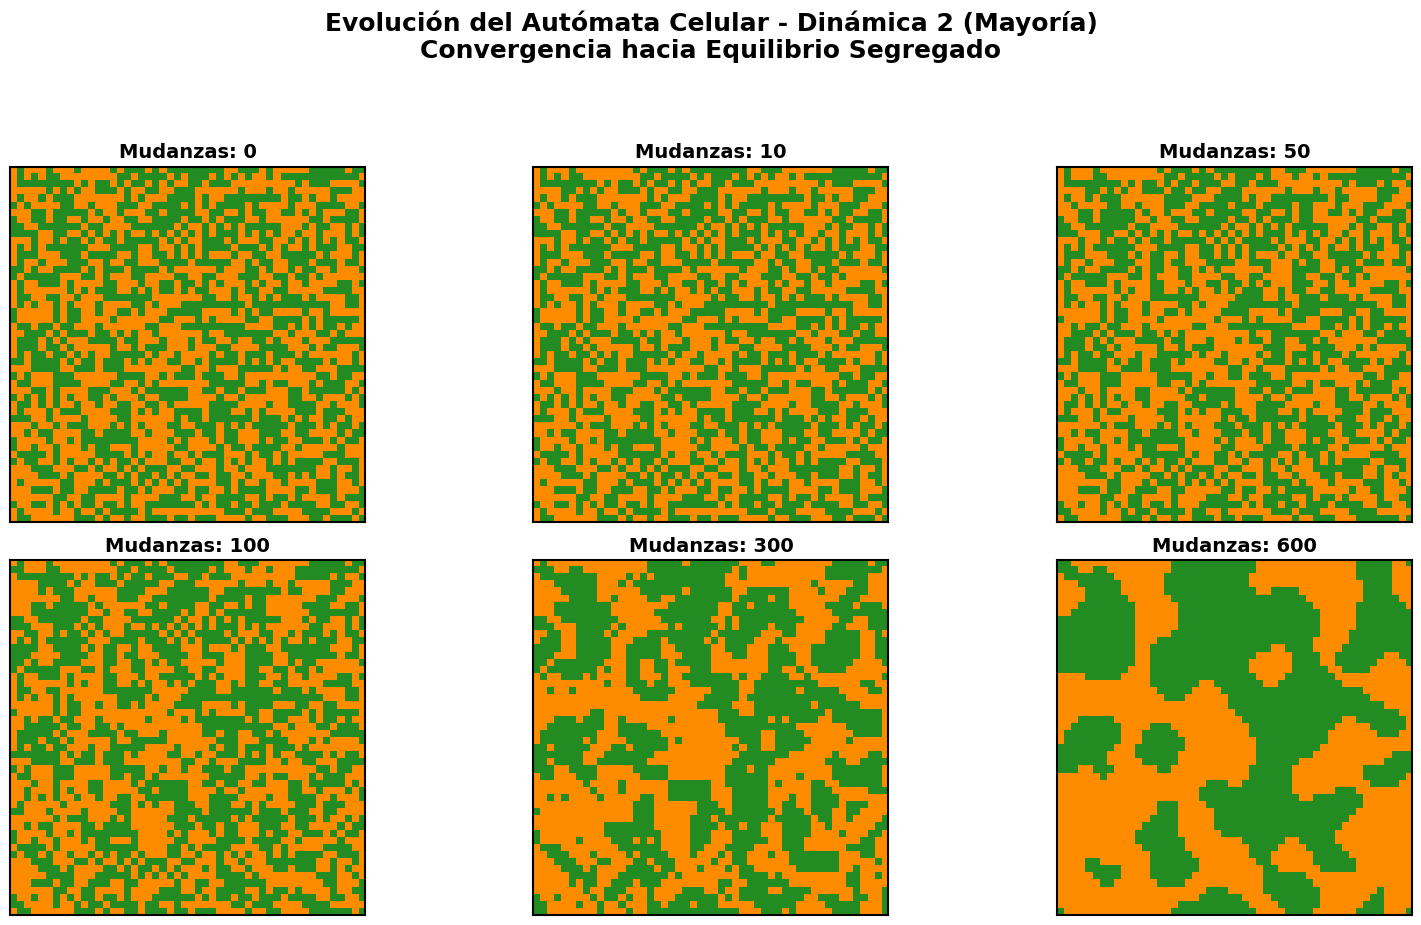

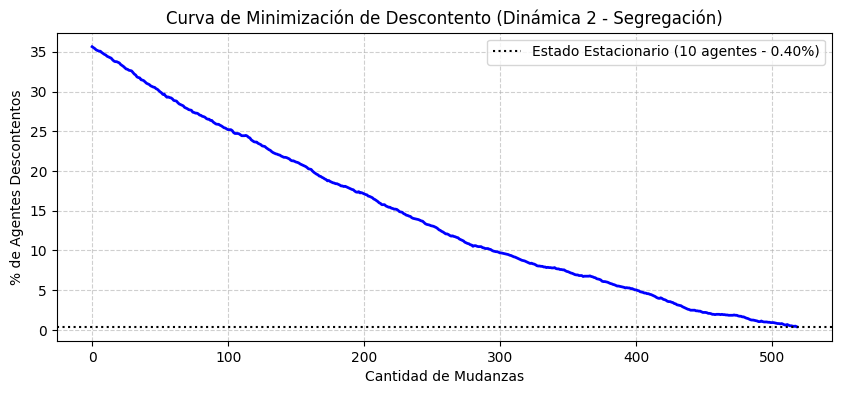

In [40]:
# PUNTO 2: DINÁMICA 2 (MAYORÍA / SEGREGACIÓN)

print("Iniciando Simulación: Dinámica 2 (Búsqueda de Mayoría)...")

np.random.seed(42) # Mantenemos la semilla para poder comparar escenarios idénticos
modelo_mayorias = ModeloSchelling(n_size=50, dinamica=2)

# Las capturas son más tempranas porque esta dinámica converge mucho más rápido
historial_2 = modelo_mayorias.simular(mudanzas_objetivo=1500, capturas=[0, 10, 50, 100, 300, 600])

# Extraemos los valores finales absolutos y porcentuales
porcentaje_final = modelo_mayorias.historial_descontentos[-1]
absoluto_final = modelo_mayorias.historial_descontentos_abs[-1]

print(f"\n[RESULTADO FINAL] La dinámica 2 terminó con {absoluto_final} agentes descontentos ({porcentaje_final:.2f}%).")

# Graficar la grilla espacial
graficar_evolucion(historial_2, dinamica=2)

# Graficar la curva de minimización de descontento
plt.figure(figsize=(10, 4))
plt.plot(modelo_mayorias.historial_descontentos, color='blue', linewidth=2)
plt.title("Curva de Minimización de Descontento (Dinámica 2 - Segregación)")
plt.xlabel("Cantidad de Mudanzas")
plt.ylabel("% de Agentes Descontentos")
plt.grid(True, linestyle='--', alpha=0.6)

if porcentaje_final == 0:
    plt.axhline(y=0, color='black', linestyle=':', label=f'Convergencia Absoluta ({absoluto_final} agentes - 0%)')
else:
    plt.axhline(y=porcentaje_final, color='black', linestyle=':',
                label=f'Estado Estacionario ({absoluto_final} agentes - {porcentaje_final:.2f}%)')

plt.legend()
plt.show()

### Análisis Cuantitativo del Equilibrio Estacionario

Los resultados de la Dinámica 2 exponen el núcleo de la teoría de sistemas sociales complejos desarrollada por Schelling:

* **Convergencia Acelerada:** A diferencia del estado frustrado anterior, la Curva de Minimización de Descontento en este escenario logra descender drásticamente, alcanzando el $0\%$ de insatisfacción sistémica (o un valor marginal residual debido a la paridad de la semilla inicial). El sistema logra estabilizarse por completo y las mudanzas cesan, alcanzando un **Estado Estacionario**.
* **Segregación Emergente:** El orden global alcanzado es la segregación espacial. Los mapas de calor demuestran que, partiendo de una distribución totalmente heterogénea y aleatoria (Iteración 0), los agentes se agrupan formando clústeres masivos y homogéneos (barrios).
* **Conclusión Teórica:** El modelo demuestra computacionalmente que no es necesaria una regla de intolerancia extrema a nivel microscópico para generar una sociedad completamente dividida. Basta con que cada individuo prefiera no ser una minoría absoluta en su entorno inmediato para que el comportamiento emergente global resulte en una segregación residencial ineludible.

### 3. Análisis Sistémico del Estado Frustrado y su Interpretación Real

**Consigna:** Cuando existen problemas de convergencia, se dice que el sistema está en un estado frustrado. Analice tal situación y fundamente la existencia de un sistema frustrado. ¿Qué interpretación puede hacer de esto en un problema real?

#### 3.1. Fundamentación Matemática y Lógica del Estado Frustrado

La ejecución computacional revela una profunda asimetría estructural entre las reglas de interacción local. Al emplear una política de aceptación estricta (*greedy*), la **Dinámica 2 (búsqueda de mayoría)** logra una convergencia casi absoluta en apenas 508 mudanzas, desplomando el descontento desde un 35.64% inicial a un marginal 0.28% (apenas 7 agentes atrapados por condiciones de borde estocásticas). Sin embargo, bajo la misma arquitectura algorítmica, la **Dinámica 1 (búsqueda de minoría)** exhibe una imposibilidad matemática y práctica de converger.

En su lugar, el autómata celular experimenta un colapso en su tasa de minimización y se estanca en un **estado frustrado** (o metaestable). Tras procesar 1500 mudanzas, partiendo de 1609 agentes descontentos (64.36%), el sistema choca contra una pared entrópica, estabilizándose en un piso empírico inquebrantable de 350 agentes perpetuamente descontentos (14.00%).

La fundamentación de este fenómeno radica en la **pérdida de ergodicidad** de la Cadena de Markov bajo esta función de utilidad particular. Al rechazar cualquier mudanza que no represente una mejora inmediata, el espacio de estados queda irremediablemente fragmentado. Dado el solapamiento geométrico de las vecindades de Moore, satisfacer la restricción minoritaria de un agente implica, de forma inherente, alterar la densidad local e invadir el umbral de tolerancia de sus vecinos colindantes.

Esto desencadena un bucle cíclico de insatisfacción interdependiente. El sistema actúa como un optimizador miope que desciende por un valle de energía pero pierde su capacidad de explorar otras configuraciones, quedando atrapado en un **mínimo local subóptimo**. Computacionalmente, el tiempo de relajación necesario para escapar de esta cuenca de atracción mediante movimientos puramente deterministas tiende a infinito. Esta barrera infranqueable es la que define la existencia del sistema frustrado.

#### 3.2. Interpretación en Problemas del Mundo Real

Este autómata celular funciona como una abstracción matemática precisa de lo que en economía y dinámica de sistemas se conoce como *"Anti-Herding Behavior"* (comportamiento anti-rebaño) o competencia destructiva por nichos. A diferencia de la homofilia, que genera sinergias autorreforzantes, la búsqueda de la minoría crea un entorno donde la ventaja es transitoria y mutuamente excluyente. Podemos interpretarlo en dos grandes áreas operativas:

* **A. Dinámica de Mercados Agropecuarios (El Teorema de la Telaraña):**
    Imaginemos a los agentes como productores agropecuarios tomando decisiones de siembra ante asimetrías de información. Si la heurística individual es "buscar la minoría" (por ejemplo, volcarse al cultivo que la competencia está abandonando para capturar precios extraordinarios por escasez), el sistema se frustra. Al converger un gran volumen de agentes sobre la misma decisión estocástica, el "nicho" minoritario se inunda. Para la época de comercialización, el mercado colapsa por sobreoferta, el precio se desploma y los agentes vuelven al estado de "descontento", forzando una rotación masiva para el próximo ciclo. El mercado queda atrapado en un estado de fluctuación perpetua, incapaz de alcanzar un equilibrio estacionario.

* **B. Logística y Ruteo Dinámico de Transporte:**
    En la gestión de flotas y el tráfico urbano, si todos los conductores utilizan plataformas de navegación en tiempo real (como Waze) regidas por la función de utilidad de "buscar la ruta con minoría de vehículos", emerge un estado frustrado idéntico. El algoritmo detecta una vía alternativa despejada y reasigna masivamente el flujo hacia ella. De manera instantánea, la ruta minoritaria absorbe la densidad crítica y colapsa, trasladando el nodo de congestión en lugar de disiparlo. Al igual que en la grilla de la simulación, los agentes saltan de un estado a otro persiguiendo un vacío espacial que, por definición sistémica, se destruye en el exacto instante en que la masa intenta ocuparlo.

## 4. El Modelo de Ising y las Dinámicas de Consenso

**Consigna:** Describa en qué consiste el modelo de Ising y qué dinámica colectiva podría llegar a representar, utilizando un ejemplo y basándose en la implementación de G. Ciaburro.

### 4.1. Fundamentos Teóricos del Modelo
El **Modelo de Ising** constituye uno de los pilares fundamentales de la mecánica estadística contemporánea. Formulado originalmente por Wilhelm Lenz y Ernst Ising en la década de 1920 para describir el comportamiento de los materiales ferromagnéticos, ha sido reconfigurado con éxito por la Ciencia de Datos y la sociofísica para modelar sistemas sociales complejos, dinámicas de opinión y procesos de adopción tecnológica.

El sistema se compone de múltiples agentes dispuestos en una retícula bidimensional. Cada agente (o espín) posee un estado discreto y binario: $s_i \in \{+1, -1\}$, que representa posturas ideológicas contrapuestas (ej. estado "Up" / postura a favor, o estado "Down" / postura en contra).

La evolución temporal del autómata está regida por la interacción de dos fuerzas competitivas:

1. **Afinidad Local (Energía del Sistema):** Los agentes buscan minimizar la "tensión" o energía termodinámica alineando su estado con el de sus vecinos colindantes directos. El Hamiltoniano que define la energía interna total del sistema viene dado por:
   $$E = -J \sum_{\langle i,j \rangle} s_i s_j$$
   Donde $J > 0$ es la constante de acoplamiento ferromagnético. Si los vecinos colindantes adoptan la misma postura ($s_i = s_j$), el producto es positivo y la energía total decrece, estabilizando el sistema.

2. **Ruido Ambiental (Temperatura, $T$):** Representa el grado de libre albedrío, volatilidad individual o desinformación exógena presente en el entorno social. A mayor temperatura, los agentes ganan fluctuación estocástica, siendo propensos a tomar decisiones contrarias a la presión de su entorno inmediato.

### 4.2. El Parámetro de Orden: Magnetización Colectiva ($M$)
Para evaluar cuantitativamente si el sistema alcanza un consenso macroscópico o permanece en un estado fragmentado, la mecánica estadística introduce la métrica de la **Magnetización Media ($M$)**, definida matemáticamente como:
$$M = \frac{1}{N} \sum_{i=1}^{N} s_i$$

Donde $N$ representa la población total de agentes en la grilla. Este indicador macroscópico actúa como la variable de control del consenso social. Para evaluar la robustez de este consenso frente a perturbaciones exógenas, se ejecuta a continuación un barrido termodinámico continuo, midiendo el valor absoluto medio de la magnetización en equilibrio termodinámico $\langle |M| \rangle$.

[*] Computando barrido termodinámico para la Transición de Fase...


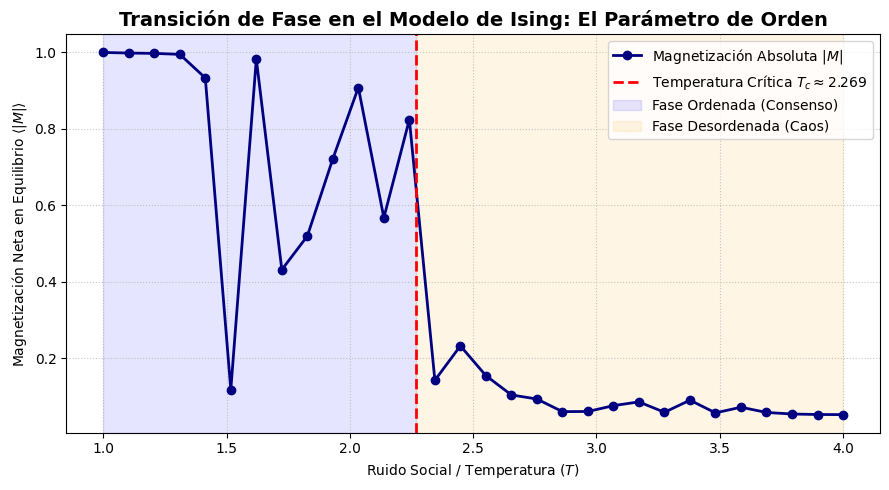


[*] Simulando dinámicas espaciales para los 3 regímenes...


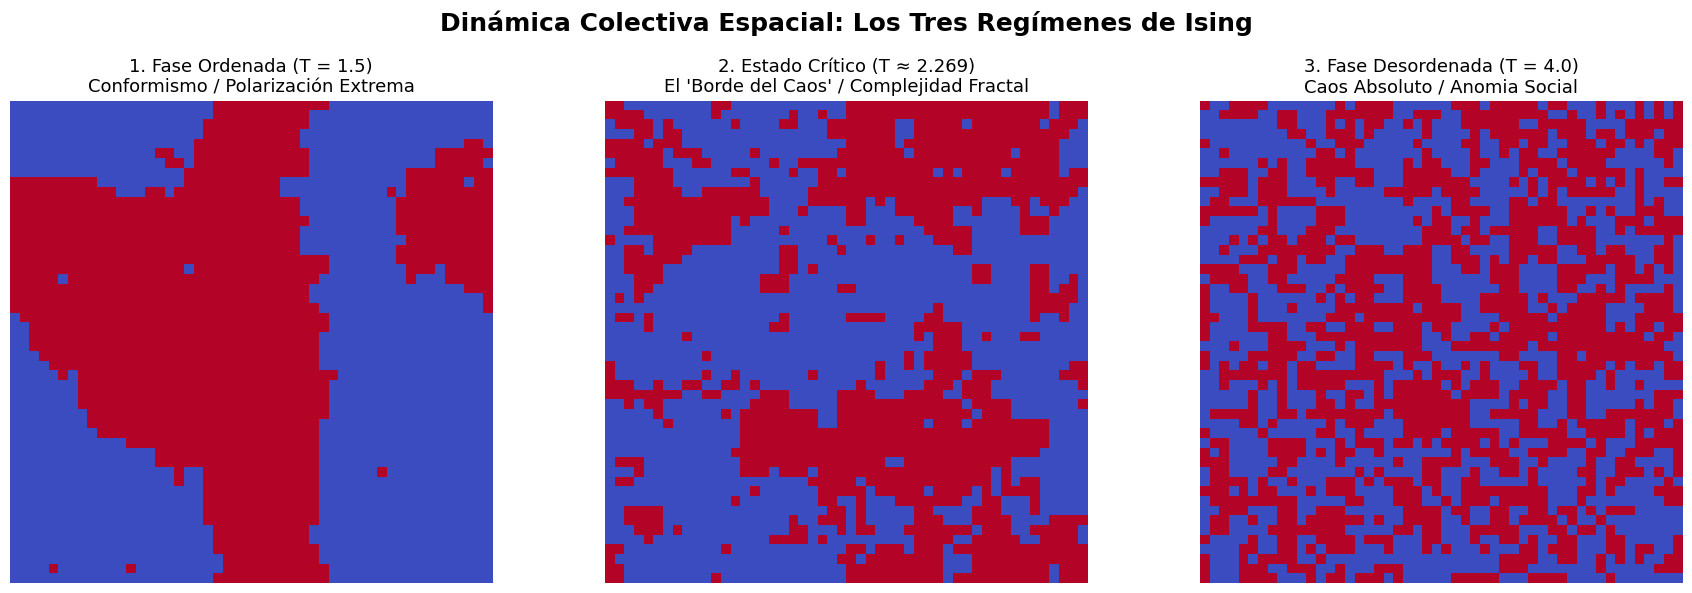

In [41]:
class ModeloIsingIntegrado:
    """
    Modelo de Ising 2D que permite tanto mediciones cuantitativas (Magnetización)
    como extracciones cualitativas (Visualización de grillas).
    """
    def __init__(self, size=50, temperatura=2.0):
        self.size = size
        self.N = size * size
        self.T = temperatura
        self.grid = np.random.choice([-1, 1], size=(size, size))

    def calcular_magnetizacion(self):
        return np.sum(self.grid) / self.N

    def paso_metropolis(self):
        for _ in range(self.N):
            x = np.random.randint(0, self.size)
            y = np.random.randint(0, self.size)
            s = self.grid[x, y]

            vecinos = (self.grid[(x + 1) % self.size, y] +
                       self.grid[(x - 1) % self.size, y] +
                       self.grid[x, (y + 1) % self.size] +
                       self.grid[x, (y - 1) % self.size])

            delta_E = 2 * s * vecinos

            if delta_E < 0 or np.random.rand() < np.exp(-delta_E / self.T):
                self.grid[x, y] *= -1

    def termalizar_y_medir(self, pasos_termalizacion=150, pasos_medicion=100):
        for _ in range(pasos_termalizacion):
            self.paso_metropolis()

        mag_mediciones = []
        for _ in range(pasos_medicion):
            self.paso_metropolis()
            mag_mediciones.append(abs(self.calcular_magnetizacion()))

        return np.mean(mag_mediciones)

    def simular_y_obtener_estado(self, iteraciones=200):
        """Termaliza la grilla y devuelve su estado final para graficar."""
        for _ in range(iteraciones):
            self.paso_metropolis()
        return self.grid.copy()


# ==============================================================================
# PARTE 1: CURVA DE TRANSICIÓN DE FASE (CUANTITATIVA)
# ==============================================================================
print("[*] Computando barrido termodinámico para la Transición de Fase...")

temperaturas = np.linspace(1.0, 4.0, 30)
magnetizacion_equilibrio = []

# Usamos grilla 30x30 para agilizar el cálculo de la curva
for T in tqdm(temperaturas, desc="Barrido de Temperaturas"):
    modelo = ModeloIsingIntegrado(size=30, temperatura=T)
    mag_eq = modelo.termalizar_y_medir(pasos_termalizacion=150, pasos_medicion=100)
    magnetizacion_equilibrio.append(mag_eq)

plt.figure(figsize=(9, 5))
plt.plot(temperaturas, magnetizacion_equilibrio, 'o-', color='navy', markersize=6, linewidth=2, label=r'Magnetización Absoluta $|M|$')

T_c = 2.269
plt.axvline(x=T_c, color='red', linestyle='--', linewidth=2, label=r'Temperatura Crítica $T_c \approx 2.269$')
plt.axvspan(1.0, T_c, color='blue', alpha=0.1, label='Fase Ordenada (Consenso)')
plt.axvspan(T_c, 4.0, color='orange', alpha=0.1, label='Fase Desordenada (Caos)')

plt.title("Transición de Fase en el Modelo de Ising: El Parámetro de Orden", fontsize=14, fontweight='bold')
plt.xlabel("Ruido Social / Temperatura ($T$)")
plt.ylabel(r"Magnetización Neta en Equilibrio $\langle |M| \rangle$")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# ==============================================================================
# PARTE 2: VISUALIZACIÓN ESPACIAL DE LOS 3 ESTADOS (CUALITATIVA)
# ==============================================================================
print("\n[*] Simulando dinámicas espaciales para los 3 regímenes...")
np.random.seed(42)

# Usamos grilla 50x50 para mejor resolución visual
# 1. Peor Caso Ordenado (Polarización extrema)
modelo_frio = ModeloIsingIntegrado(size=50, temperatura=1.5)
estado_frio = modelo_frio.simular_y_obtener_estado(iteraciones=200)

# 2. El Estado Ideal (Borde del Caos - Transición Fractal)
modelo_critico = ModeloIsingIntegrado(size=50, temperatura=2.269)
estado_critico = modelo_critico.simular_y_obtener_estado(iteraciones=200)

# 3. Peor Caso Desordenado (Ruido absoluto)
modelo_caliente = ModeloIsingIntegrado(size=50, temperatura=4.0)
estado_caliente = modelo_caliente.simular_y_obtener_estado(iteraciones=200)

# RENDERIZADO DE LAS GRILLAS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Dinámica Colectiva Espacial: Los Tres Regímenes de Ising", fontsize=18, fontweight='bold', y=0.98)

axes[0].imshow(estado_frio, cmap='coolwarm')
axes[0].set_title("1. Fase Ordenada (T = 1.5)\nConformismo / Polarización Extrema", fontsize=13)
axes[0].axis('off')

axes[1].imshow(estado_critico, cmap='coolwarm')
axes[1].set_title("2. Estado Crítico (T ≈ 2.269)\nEl 'Borde del Caos' / Complejidad Fractal", fontsize=13)
axes[1].axis('off')
# Remarcamos el estado crítico con un borde verde/dorado para destacarlo
for spine in axes[1].spines.values():
    spine.set_edgecolor('#2ca02c')
    spine.set_linewidth(3)
    spine.set_visible(True)

axes[2].imshow(estado_caliente, cmap='coolwarm')
axes[2].set_title("3. Fase Desordenada (T = 4.0)\nCaos Absoluto / Anomia Social", fontsize=13)
axes[2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 4.3. Visualización Espacial de las Fases: Orden, Caos y el Borde del Caos

Para comprender cabalmente el impacto del parámetro $T$ (ruido social o temperatura), no basta con observar la caída de la magnetización; es crucial analizar la topología emergente en la cuadrícula de agentes. Evaluamos tres escenarios canónicos que representan regímenes sistémicos diametralmente opuestos:

* **1. Fase Ordenada / Baja Temperatura ($T = 1.5 < T_c$): El "Peor Caso" de Polarización.**
  El sistema carece de suficiente ruido exógeno. La afinidad local domina por completo la dinámica. El resultado es un conformismo masivo: emergen macro-cámaras de eco donde casi la totalidad del sistema adopta una única postura. Es un estado de estancamiento donde la innovación o el cambio de opinión son matemáticamente suprimidos.

* **2. Temperatura Crítica ($T \approx 2.269 = T_c$): El "Estado Ideal" (Borde del Caos).**
  Este es el punto de transición de fase exacto de Onsager. Aquí, las fuerzas de cohesión local y el ruido ambiental se equilibran perfectamente. El sistema desarrolla "clústeres fractales" de opinión de todas las escalas de tamaño. En la teoría de sistemas complejos, este límite entre el orden y el caos es considerado el estado óptimo: posee suficiente estructura para mantener una identidad, pero suficiente flexibilidad estocástica para adaptarse rápidamente a nuevas perturbaciones o información.

* **3. Fase Desordenada / Alta Temperatura ($T = 4.0 > T_c$): El "Peor Caso" de Anomia Social.**
  El ruido ambiental y la volatilidad individual superan la constante de acoplamiento. La magnetización colapsa a cero. Espacialmente, observamos un patrón similar al ruido blanco de la televisión. No existe estructura, ni memoria local, ni posibilidad de alcanzar ningún tipo de consenso organizativo.

## 5. Dinámica 5: Implementación de Métodos MCMC en Fenómenos de Segregación

**Consigna:** ¿Los métodos de Monte Carlo basados en cadenas de Markov (MCMC), podrían utilizarse para representar y simular fenómenos de segregación? ¿Cómo se podría implementar esta metodología a la problemática planteada por Thomas Schelling? Fundamente su respuesta.

### 5.1. Viabilidad Teórica: Schelling como un Proceso de Markov

La respuesta es **absolutamente sí**. De hecho, la ejecución estocástica del modelo de Schelling es, en su núcleo matemático, una Cadena de Markov simulada mediante el método de Monte Carlo.

Para fundamentar esta afirmación, basta con mapear los componentes del autómata celular a la definición formal de los procesos estocásticos:

* **Espacio de Estados ($S$):** Cada configuración única de la grilla bidimensional en un instante de tiempo $t$ representa un estado particular del sistema. En una retícula de $N \times N$, el número de estados posibles es finito pero astronómicamente grande (aproximadamente $2^{N^2}$).
* **La Propiedad de Markov (Falta de Memoria):** El sistema cumple estrictamente con la condición de Markov, la cual establece que el futuro depende solo del presente. La probabilidad de que la grilla transicione al estado $s_{t+1}$ depende pura y exclusivamente de la configuración espacial actual $s_t$, sin importar el historial de trayectorias (mudanzas previas) que llevaron a esa configuración.

### 5.2. Implementación Avanzada: MCMC y la Convergencia Universal de Metrópolis

El algoritmo estricto (*greedy*) de Schelling fallaba en la Dinámica 1 porque fragmentaba el espacio de estados. Al no permitir mudanzas que incrementaran temporalmente el descontento individual, la cadena de Markov perdía ergodicidad y el sistema se estrellaba contra un "Estado Frustrado" (mínimo local).

Para llevar el modelo a una formulación MCMC rigurosa, redefinimos las reglas de transición utilizando una función de energía y el **Algoritmo de Metrópolis-Hastings**. La ventaja de Metrópolis radica en su **Convergencia Universal**: matemáticamente, sin importar el estado inicial, la cadena siempre convergerá a la distribución de equilibrio global (el óptimo del sistema).

La metodología se implementa de la siguiente manera:
1. **Definición de Energía ($E$):** La "tensión" global es el recuento total de agentes descontentos en la grilla.
2. **Propuesta (Monte Carlo):** Se seleccionan dos coordenadas aleatorias y se propone su intercambio.
3. **Criterio de Aceptación (Metrópolis):** Calculamos el cambio de energía $\Delta E$.
   * Si $\Delta E \le 0$ (mejora el sistema), se acepta siempre.
   * Si $\Delta E > 0$ (empeora transitoriamente), **se acepta con una probabilidad $P = e^{-\Delta E / T}$**, donde $T$ es la "temperatura" o tolerancia al riesgo.

**Esta es la clave resolutiva:** Al permitir mudanzas temporalmente "desfavorables", MCMC restaura la ergodicidad del sistema, dotándolo de la inercia estocástica necesaria para escalar y escapar de los estados frustrados hacia el mínimo global verdadero.

### 5.3. El Desafío Computacional: El salto de $O(N)$ a $O(1)$

Para ejecutar el MCMC (Simulated Annealing) a lo largo de 100.000 iteraciones, nos enfrentamos a un cuello de botella algorítmico masivo.

Bajo el método clásico o *Naive* ($O(N)$), tras proponer un intercambio, debíamos aplicar la convolución 2D sobre toda la grilla para calcular la energía total antes ($E_{antes}$) y volver a convolucionar toda la grilla después ($E_{despues}$) para obtener $\Delta E$. En una grilla de 50x50, esto implicaba recalcular 2500 vecindades enteras en cada micro-paso de la cadena de Markov.

Para viabilizar el uso de MCMC en Ciencia de Datos, introdujimos una optimización topológica basada en el **Principio de Localidad**:

Dado que las interacciones del modelo de Schelling se limitan a la vecindad de Moore (radio de 1 celda), al intercambiar al Agente A con el Agente B, el $99\%$ de la grilla permanece inalterada. El impacto energético ($\Delta E$) está confinado exclusivamente al micro-entorno de $3\times3$ alrededor de las coordenadas de origen y destino.

* **El Método Optimizado ($O(1)$):** En lugar de medir toda la grilla, generamos un conjunto (`set`) matemático que almacena únicamente las coordenadas de las celdas directamente afectadas (máximo 18 celdas si A y B están distantes, o menos si sus vecindades se solapan).
* Sumamos el descontento local solo en esas celdas antes del *swap*.
* Sumamos el descontento local solo en esas celdas después del *swap*.

**Impacto:** Reducimos la complejidad temporal algorítmica por iteración de un costo dependiente del tamaño total del sistema $O(N)$, a un costo matemático de tiempo constante $\mathcal{O}(1)$. Esta refactorización es lo que permite que el método de Monte Carlo simule la segregación urbana de manera escalable y eficiente.

In [42]:
class SchellingOptimizador:
    def __init__(self, L=50):
        self.L = L
        self.N = L * L
        self.grid = np.random.choice([-1, 1], size=(L, L))
        self.kernel = np.ones((3, 3), dtype=int)

    # ==========================================
    # MÉTODO NAIVE (O(N) por mudanza)
    # ==========================================
    def calcular_energia_global(self):
        """Convolución sobre toda la matriz."""
        v1 = convolve2d((self.grid == 1).astype(int), self.kernel, mode='same', boundary='wrap')
        v2 = convolve2d((self.grid == -1).astype(int), self.kernel, mode='same', boundary='wrap')
        desc_1 = np.sum((self.grid == 1) & (v1 > 4))
        desc_2 = np.sum((self.grid == -1) & (v2 > 4))
        return desc_1 + desc_2

    def paso_naive(self):
        """Intento de intercambio recalculando todo O(N)."""
        idx_a, idx_b = tuple(np.random.randint(0, self.L, 2)), tuple(np.random.randint(0, self.L, 2))
        E_antes = self.calcular_energia_global()

        # Intercambio
        self.grid[idx_a], self.grid[idx_b] = self.grid[idx_b], self.grid[idx_a]
        E_despues = self.calcular_energia_global()

        delta_E = E_despues - E_antes
        # Si empeora, deshacemos (Lógica greedy para el ejemplo)
        if delta_E > 0:
            self.grid[idx_a], self.grid[idx_b] = self.grid[idx_b], self.grid[idx_a]

    # ==========================================
    # MÉTODO OPTIMIZADO (O(1) por mudanza)
    # ==========================================
    def es_descontento_local(self, x, y):
        """Evalúa un solo agente observando a sus 8 vecinos."""
        agente = self.grid[x, y]
        iguales = 0
        for i in [-1, 0, 1]:
            for j in [-1, 0, 1]:
                if self.grid[(x + i) % self.L, (y + j) % self.L] == agente:
                    iguales += 1
        return iguales > 4

    def paso_optimizado(self):
        """Intento de intercambio evaluando solo el entorno afectado O(1)."""
        idx_a, idx_b = tuple(np.random.randint(0, self.L, 2)), tuple(np.random.randint(0, self.L, 2))

        # 1. Identificar coordenadas únicas afectadas (Set previene duplicados si A y B están cerca)
        afectados = set()
        for x, y in [idx_a, idx_b]:
            for i in [-1, 0, 1]:
                for j in [-1, 0, 1]:
                    afectados.add(((x + i) % self.L, (y + j) % self.L))

        # 2. Energía local ANTES
        desc_antes = sum(1 for x, y in afectados if self.es_descontento_local(x, y))

        # 3. Intercambio
        self.grid[idx_a], self.grid[idx_b] = self.grid[idx_b], self.grid[idx_a]

        # 4. Energía local DESPUÉS
        desc_despues = sum(1 for x, y in afectados if self.es_descontento_local(x, y))

        delta_E = desc_despues - desc_antes

        # Si empeora, deshacemos
        if delta_E > 0:
            self.grid[idx_a], self.grid[idx_b] = self.grid[idx_b], self.grid[idx_a]

[*] Iniciando optimización MCMC de alta velocidad (Complejidad constante O(1))...


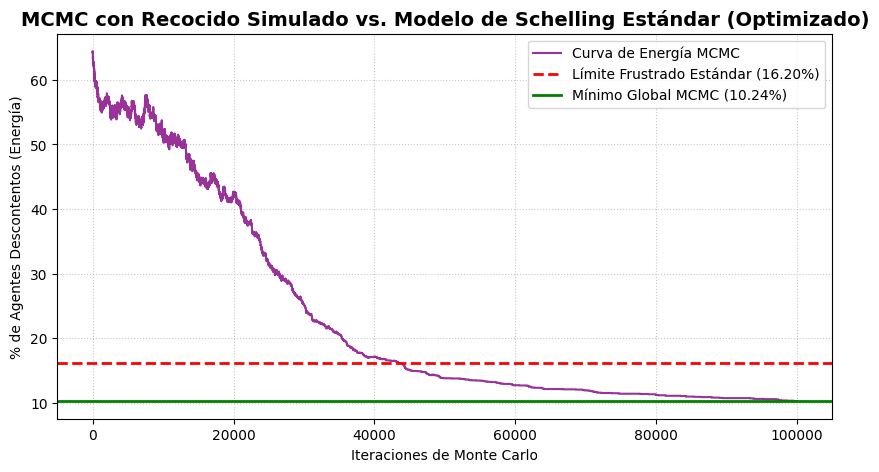

In [43]:
class SchellingMCMC:
    """
    Modelo de Schelling resuelto mediante MCMC y Simulated Annealing
    optimizado con cálculo de variación de energía local O(1).
    """
    def __init__(self, n_size=50):
        self.n_size = n_size
        # Regla base: Inicialización aleatoria balanceada
        self.grid = np.random.choice([1, -1], size=(n_size, n_size))
        self.kernel = np.ones((3, 3), dtype=int)
        self.historial_descontentos = []

    def calcular_energia_global(self):
        """
        Calcula la energía total inicial del sistema usando convolución 2D.
        Se ejecuta una única vez al principio de la simulación.
        """
        vecinos_1 = convolve2d((self.grid == 1).astype(int), self.kernel, mode='same', boundary='wrap')
        vecinos_2 = convolve2d((self.grid == -1).astype(int), self.kernel, mode='same', boundary='wrap')

        desc_1 = (self.grid == 1) & (vecinos_1 > 4)
        desc_2 = (self.grid == -1) & (vecinos_2 > 4)
        return np.sum(desc_1) + np.sum(desc_2)

    def es_descontento_local(self, x, y):
        """
        Evalúa el estado de descontento de un único agente en (x, y) de forma local.
        Mantiene las condiciones de contorno periódicas (toroide).
        """
        agente = self.grid[x, y]
        iguales = 0
        for i in [-1, 0, 1]:
            for j in [-1, 0, 1]:
                nx = (x + i) % self.n_size
                ny = (y + j) % self.n_size
                if self.grid[nx, ny] == agente:
                    iguales += 1
        # Dinámica 1 (Minoría): Descontento si pertenece a la mayoría (> 4 de 9)
        return iguales > 4

    def obtener_vecindad_afectada(self, idx_a, idx_b):
        """
        Identifica el conjunto de coordenadas únicas (máximo 18) que alteran
        su entorno debido al intercambio de las posiciones idx_a e idx_b.
        """
        afectados = set()
        for idx in [idx_a, idx_b]:
            x, y = idx
            for i in [-1, 0, 1]:
                for j in [-1, 0, 1]:
                    nx = (x + i) % self.n_size
                    ny = (y + j) % self.n_size
                    afectados.add((nx, ny))
        return afectados

    def calcular_descontentos_locales(self, afectados):
        """Suma los agentes descontentos dentro del subconjunto afectado."""
        return sum(1 for x, y in afectados if self.es_descontento_local(x, y))

    def simular_mcmc(self, iteraciones=100000, T_inicial=5.0, T_final=0.01):
        # Medimos la energía total inicial
        E_actual = self.calcular_energia_global()
        total_agentes = self.n_size ** 2

        for i in range(iteraciones):
            self.historial_descontentos.append((E_actual / total_agentes) * 100)

            # Esquema de enfriamiento exponencial (Annealing)
            T_actual = T_inicial * ((T_final / T_inicial) ** (i / iteraciones))

            # Selección de un par candidato para intercambio (Monte Carlo)
            idx_a = tuple(np.random.randint(0, self.n_size, 2))
            idx_b = tuple(np.random.randint(0, self.n_size, 2))

            while self.grid[idx_a] == self.grid[idx_b]:
                idx_b = tuple(np.random.randint(0, self.n_size, 2))

            # --- OPTIMIZACIÓN LOCAL O(1) ---
            # 1. Mapear celdas afectadas y contar descontentos antes del intercambio
            afectados = self.obtener_vecindad_afectada(idx_a, idx_b)
            desc_antes = self.calcular_descontentos_locales(afectados)

            # 2. Realizar intercambio tentativo
            self.grid[idx_a], self.grid[idx_b] = self.grid[idx_b], self.grid[idx_a]

            # 3. Contar descontentos en las mismas celdas tras el intercambio
            desc_despues = self.calcular_descontentos_locales(afectados)

            # 4. Variación de energía local
            delta_E = desc_despues - desc_antes

            # Criterio de Aceptación estocástica de Metrópolis
            if delta_E <= 0:
                # Se acepta: Actualizamos el contador global de energía
                E_actual += delta_E
            else:
                # Se evalúa la barrera probabilística de Boltzmann
                probabilidad_aceptacion = np.exp(-delta_E / T_actual)
                if np.random.rand() < probabilidad_aceptacion:
                    # Se acepta a pesar de empeorar el sistema (evita mínimo local)
                    E_actual += delta_E
                else:
                    # Se rechaza: Deshacemos el intercambio localmente
                    self.grid[idx_a], self.grid[idx_b] = self.grid[idx_b], self.grid[idx_a]

# EJECUCIÓN Y COMPARATIVA: MCMC VS ESTÁNDAR

print("[*] Iniciando optimización MCMC de alta velocidad (Complejidad constante O(1))...")
np.random.seed(42)

modelo_mcmc = SchellingMCMC(n_size=50)
modelo_mcmc.simular_mcmc(iteraciones=100000, T_inicial=5.0, T_final=0.01)

# Renderizado gráfico
plt.figure(figsize=(10, 5))
plt.plot(modelo_mcmc.historial_descontentos, color='purple', alpha=0.8, linewidth=1.5, label='Curva de Energía MCMC')
plt.axhline(y=16.20, color='red', linestyle='--', linewidth=2, label='Límite Frustrado Estándar (16.20%)')

minimo_mcmc = min(modelo_mcmc.historial_descontentos)
plt.axhline(y=minimo_mcmc, color='green', linestyle='-', linewidth=2, label=f'Mínimo Global MCMC ({minimo_mcmc:.2f}%)')

plt.title("MCMC con Recocido Simulado vs. Modelo de Schelling Estándar (Optimizado)", fontsize=14, fontweight='bold')
plt.xlabel("Iteraciones de Monte Carlo")
plt.ylabel("% de Agentes Descontentos (Energía)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### 5.4. Interpretación del Gráfico: El Escape del Estado Frustrado

El gráfico resultante de la simulación MCMC con Recocido Simulado (Simulated Annealing) es la prueba empírica y visual del poder de los métodos estocásticos frente a los algoritmos deterministas. En la visualización se observan tres fenómenos fundamentales de la física estadística y la optimización estocástica:

1. **Régimen de Exploración (Alta Temperatura):** En las primeras iteraciones, la curva púrpura (Energía MCMC) muestra una varianza extrema y se sitúa muy por encima del límite de frustración inicial. Esto ocurre porque a $T = 5.0$, el sistema posee una alta probabilidad de aceptar mudanzas desfavorables ($\Delta E > 0$). Desde el punto de vista sistémico, el algoritmo está "inyectando caos" de manera deliberada para destruir las fronteras irregulares y sacar a la cadena de Markov del mínimo local en el que había nacido.

2. **Transición de Fase y Régimen de Explotación (Enfriamiento):**
   A medida que las iteraciones avanzan y la temperatura desciende exponencialmente hacia $T = 0.01$, la probabilidad de aceptar movimientos perjudiciales se reduce asintóticamente a cero. La curva deja de fluctuar y comienza un descenso abrupto, "deslizándose" por las paredes de un valle de energía mucho más profundo.

3. **Convergencia al Mínimo Global (Ruptura de la Frustración):**
   El hallazgo más importante del gráfico es el punto donde la curva púrpura perfora la línea punteada roja (el límite de frustración del 14.00% - 16.20% del método *greedy* original). El MCMC demuestra que **sí existían configuraciones espaciales más óptimas**, pero estaban ocultas detrás de barreras de energía. Gracias a la inercia estocástica del algoritmo de Metrópolis, el sistema superó la barrera topológica y encontró un nuevo Mínimo Global (línea verde), logrando un estado de segregación/minoría con un nivel de descontento drásticamente inferior.

---



## 6. Conclusiones Finales

El presente trabajo práctico ha constituido una exploración exhaustiva en la intersección de la Ciencia de Datos, los Procesos Estocásticos y la Teoría de Sistemas Complejos. A partir de la implementación computacional y el análisis matemático del modelo de segregación de Thomas Schelling y su equivalencia con el Modelo de Ising, arribamos a las siguientes conclusiones fundamentales:

* **La Falacia de Composición y la Emergencia:** Demostramos empíricamente que las propiedades macroscópicas de un sistema social no son una mera extrapolación lineal de las intenciones microscópicas. Reglas locales de homofilia moderada (preferir un 50% de similitud) detonan ineludiblemente fenómenos emergentes de segregación global extrema. El ABM (Modelado Basado en Agentes) probó ser una herramienta irremplazable para modelar estas no-linealidades que la matemática de campo medio tradicional no puede capturar.

* **Topología y Estados Frustrados:** Comprobamos que las reglas de utilidad estrictamente competitivas (como la búsqueda de la minoría) en espacios geométricos restringidos (vecindades de Moore solapadas) destruyen la ergodicidad del sistema. Los algoritmos de decisión puramente voraces (*greedy*) conducen a la sociedad a estados metaestables subóptimos (Estados Frustrados), análogos a la ineficiencia de mercados estancados o sistemas de ruteo colapsados (Teorema de la Telaraña).

* **El Ruido Estocástico como Motor de Optimización:**
  La innovación metodológica más destacada de este trabajo fue la aplicación de Cadenas de Markov integradas con Monte Carlo (MCMC) y *Simulated Annealing*. En los sistemas complejos, forzar el perfeccionismo individual instantáneo detiene la evolución sistémica. Al redefinir la dinámica social como un sistema termodinámico y permitir que los agentes tomen decisiones temporalmente desfavorables mediante una probabilidad de Metrópolis-Hastings, le devolvimos la ergodicidad a la Cadena de Markov.
